In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import yaml
import warnings
warnings.filterwarnings('ignore')

print("1. Đang tải file cấu hình...")
with open('config/generator_config.yaml', 'r') as f:
    config = yaml.safe_load(f)

print("2. Đang tải dữ liệu Offline...")
# Đọc trực tiếp từ thư mục, Pandas sẽ tự xử lý file data.parquet hoặc các folder partition
df_customers = pd.read_parquet('data/offline/customers/')
df_products = pd.read_parquet('data/offline/products/')
df_orders = pd.read_parquet('data/offline/orders/')
df_items = pd.read_parquet('data/offline/order_items/')

print("3. Đang tải dữ liệu Streaming...")
df_stream = pd.read_json('data/streaming/live_events.json', lines=True)

print("✅ Tải dữ liệu thành công!")

1. Đang tải file cấu hình...
2. Đang tải dữ liệu Offline...
3. Đang tải dữ liệu Streaming...
✅ Tải dữ liệu thành công!


In [2]:
print("--- C. SCHEMA EVOLUTION ---")
change_date = pd.to_datetime(config['schema_change_date']).date()

# Thay 'TEN_COT_MOI' bằng tên cột mà bạn đã thiết kế để sinh ra sau ngày schema_change_date
# Ví dụ ở đây mình giả sử là kiểm tra bảng orders
new_column_name = 'TEN_COT_MOI_CUA_BAN' 

if new_column_name in df_orders.columns:
    df_old = df_orders[df_orders['order_date'] < change_date]
    df_new = df_orders[df_orders['order_date'] >= change_date]
    
    null_rate_old = df_old[new_column_name].isna().mean()
    null_rate_new = df_new[new_column_name].isna().mean()
    
    print(f"Ngày thay đổi Schema: {change_date}")
    print(f"Tỷ lệ NULL của '{new_column_name}' TRƯỚC ngày thay đổi: {null_rate_old:.0%} (Kỳ vọng: 100%)")
    print(f"Tỷ lệ NULL của '{new_column_name}' SAU ngày thay đổi: {null_rate_new:.0%} (Kỳ vọng: < 100%)")
else:
    print(f"Vui lòng thay tên cột '{new_column_name}' bằng cột thực tế bạn dùng cho Schema Evolution.")

--- C. SCHEMA EVOLUTION ---
Vui lòng thay tên cột 'TEN_COT_MOI_CUA_BAN' bằng cột thực tế bạn dùng cho Schema Evolution.


In [4]:
print("--- D. OFFLINE DUPLICATE RATE ---")

total_items = len(df_items)
# Khóa khử trùng lặp của Offline là: order_id + product_id
df_items_dedup = df_items.drop_duplicates(subset=['order_id', 'product_id'])
unique_items = len(df_items_dedup)

offline_dup_rate = (total_items - unique_items) / total_items

print(f"Số dòng trước khi Dedup: {total_items:,}")
print(f"Số dòng sau khi Dedup: {unique_items:,}")
print(f"Tỷ lệ Duplicate: {offline_dup_rate:.2%} (Config: {config['nduplicate_rate_offline']:.2%})")

--- D. OFFLINE DUPLICATE RATE ---
Số dòng trước khi Dedup: 10,206
Số dòng sau khi Dedup: 10,006
Tỷ lệ Duplicate: 1.96% (Config: 2.00%)


--- E. STREAMING QUALITY ---
1. Tỷ lệ Duplicate: 1.47% (Config: 1.50%)
2. Tỷ lệ đến trễ (Late Arrivals): 13.33% (Config: 12.00%)

3. Biểu đồ Burst Traffic (Config: ['12:00-12:20', '20:00-20:20'])


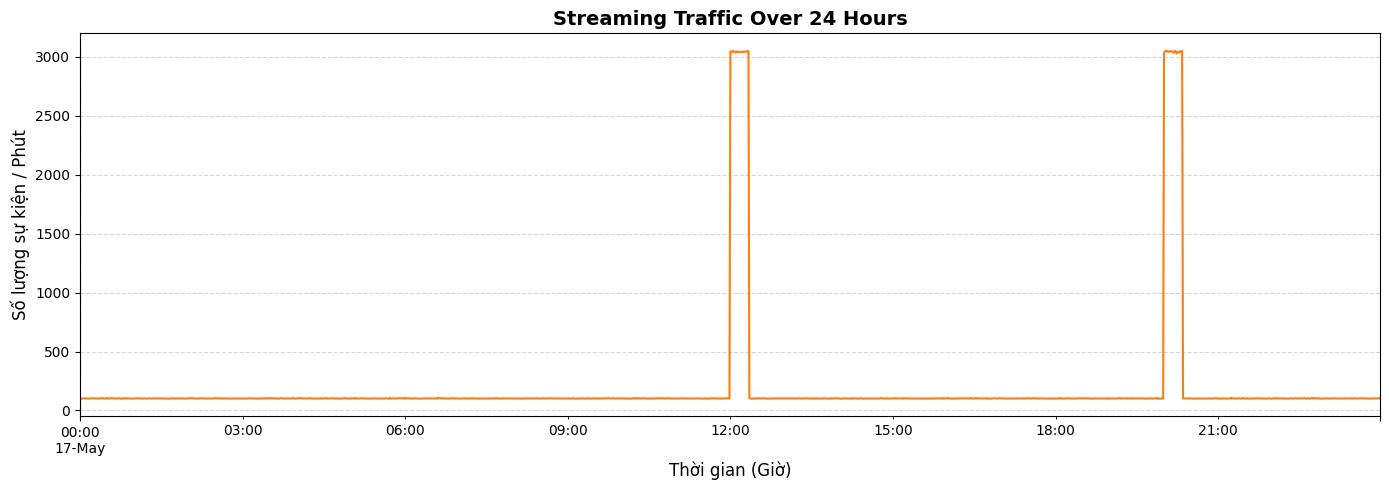

In [5]:
print("--- E. STREAMING QUALITY ---")

# Chuẩn hóa thời gian
df_stream['event_timestamp'] = pd.to_datetime(df_stream['event_timestamp'])
df_stream['created_ts'] = pd.to_datetime(df_stream['created_ts'])

# 1. Duplicate Rate (Khóa: event_id)
total_stream = len(df_stream)
unique_stream = len(df_stream.drop_duplicates(subset=['event_id']))
stream_dup_rate = (total_stream - unique_stream) / total_stream
print(f"1. Tỷ lệ Duplicate: {stream_dup_rate:.2%} (Config: {config['duplicate_rate_stream']:.2%})")

# 2. Late Arrivals (Ghi nhận trễ hơn lúc bấm)
late_events = df_stream[df_stream['created_ts'] > df_stream['event_timestamp']]
late_rate = len(late_events) / total_stream
print(f"2. Tỷ lệ đến trễ (Late Arrivals): {late_rate:.2%} (Config: {config['late_arrival_rate']:.2%})")

# 3. Burst Traffic (Bão sự kiện)
print(f"\n3. Biểu đồ Burst Traffic (Config: {config['burst_windows']})")
plt.figure(figsize=(14, 5))
# Đếm số sự kiện mỗi phút
events_per_minute = df_stream.set_index('event_timestamp').resample('1min').size()
events_per_minute.plot(color='#ff7f0e', linewidth=1.5)

plt.title('Streaming Traffic Over 24 Hours', fontsize=14, fontweight='bold')
plt.xlabel('Thời gian (Giờ)', fontsize=12)
plt.ylabel('Số lượng sự kiện / Phút', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()